In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import numpy as np

spark = SparkSession.builder.master("local[10]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("/home/h487/notebooks/jan2026/srppac/parquet/run1082_srppac.parquet").select("id_x","timing_x","charge_x","id_y","timing_y","charge_y")
df.show(5)

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|                id_x|            timing_x|            charge_x|                id_y|            timing_y|            charge_y|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|  [10, 11, 9, 12, 8]|[-42.855584961420...|[111.690349020354...|[26, 27, 25, 24, 28]|[-43.036969545006...|[110.119847501686...|
|     [11, 10, 12, 9]|[-43.813359526917...|[106.093720586024...|[22, 21, 23, 20, 24]|[-43.901744399132...|[107.264356578190...|
|    [21, 22, 20, 23]|[-42.623632493836...|[95.5185021940851...|    [12, 11, 13, 10]|[-43.479324765212...|[99.6573905108380...|
|[15, 16, 14, 17, 13]|[-41.504576558538...|[97.7942121998057...|[18, 19, 17, 20, 16]|[-43.358835988095...|[101.643548727384...|
|    [14, 15, 13, 16]|[-43.654717788493...|[113.505652495543...|[13, 14, 12, 11, 15]|[-42.403476733416..

Statistics:
[[0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 6.1581e+04 0.0000e+00]
 [0.0000e+00 4.0000e+01 0.0000e+00]]
Statistics:
[[0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 6.1177e+04 0.0000e+00]
 [0.0000e+00 2.3000e+01 0.0000e+00]]
Statistics:
[[    0.     0.     0.]
 [    0. 61621.     0.]
 [    0.     0.     0.]]
Statistics:
[[0.0000e+00 1.0000e+00 0.0000e+00]
 [0.0000e+00 6.1199e+04 0.0000e+00]
 [0.0000e+00 0.0000e+00 0.0000e+00]]


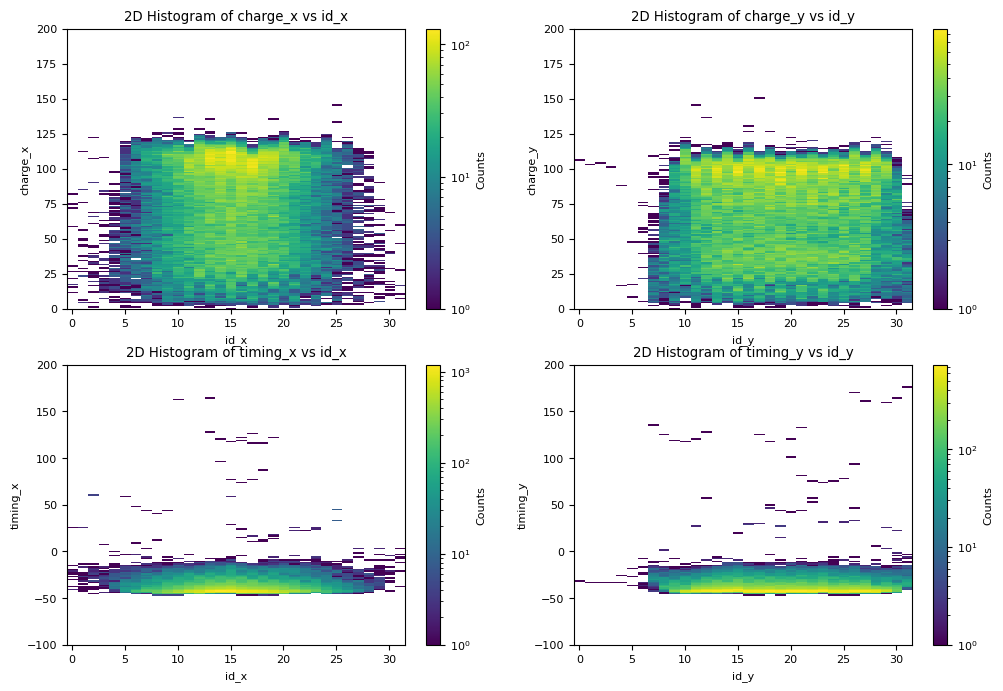

In [3]:
from hist.sparkHist2d import Hist2DArrays
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(0, figsize=(12,8))
plt.rcParams["font.size"] = 8
plt.subplot2grid((2,2),(0,0))
h = Hist2DArrays(df, ["id_x","charge_x"], [33,200], [[-0.5, 31.5], [0, 200]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,2),(0,1))
h = Hist2DArrays(df, ["id_y","charge_y"], [33,200], [[-0.5, 31.5], [0, 200]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,2),(1,0))
h = Hist2DArrays(df, ["id_x","timing_x"], [33,200], [[-0.5, 31.5], [-100, 200]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,2),(1,1))
h = Hist2DArrays(df, ["id_y","timing_y"], [33,200], [[-0.5, 31.5], [-100, 200]], norm=LogNorm(), interpolation='none')

plt.show()